# Program 3 Report
**Team Members:** Alex Ausan, Hayden Park, Eric Van Zant

## Approach To Solving Problem
To find the longest common substring, we build a grid where each row represents a character from the first string and each column represents a character from the second string. Each cell in the grid stores the length of the longest common substring that ends at that particular pair of characters. If the two characters for a cell don't match, the cell is zero. If they do match, we look one step diagonally up and to the left and add one to whatever value is there — this extends the common substring that ended at the previous pair. By filling the grid this way from top-left to bottom-right, every cell we need is always ready before we need it. Once the grid is complete, the largest number in it tells us how long the answer is, and where in the first string it ends.

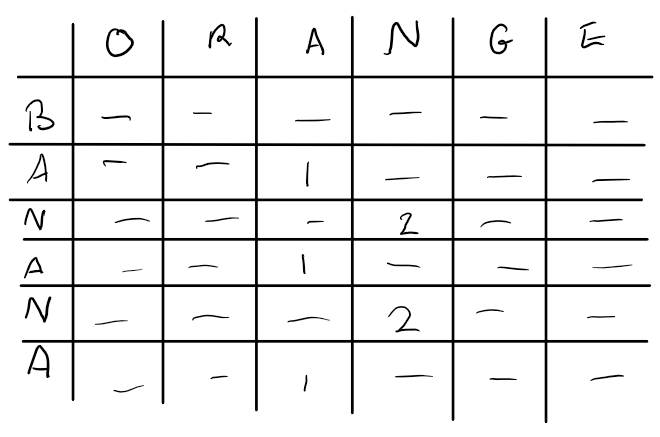

Each numbered cell marks a matching character. The matches are shown in a diagonal pattern because a common substring of length 2 or more always appears as a sequence of cells stepping down and to the right, each one building on the cell above-left of it. The longest diagonal is the answer.
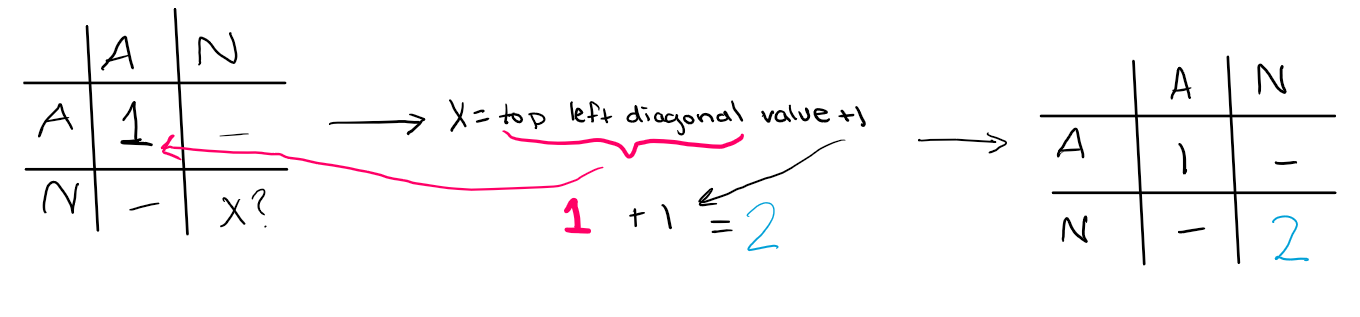


## Pseudocode
We first started by implementing the basic backtracking algorithm, which is shown below. It works by considering every possible pair of positions, one in each string, as a candidate ending point for a common substring. At each pair, it recurses backwards through both strings simultaneously, counting how many consecutive matching characters it can find before hitting a mismatch or the start of either string. The outer loop collects the longest result found across all pairs and uses it to recover the actual substring at the end.

function MAXIMALSUBSTRING(a, b):
    best_len ← 0
    best_end_a ← 0

    for i from 0 to |a| - 1:
        for j from 0 to |b| - 1:
            length ← LCS(a, b, i, j)
            if length > best_len:
                best_len ← length
                best_end_a ← i

    return SLICE(a, best_end_a - best_len + 1, best_end_a + 1)

function LCS(a, b, i, j):
    if i < 0 or j < 0:
        return 0
    if a[i] ≠ b[j]:
        return 0
    return 1 + LCS(a, b, i - 1, j - 1)


The next was to memoize this backtracking algorithm to make it more efficient. The backtracking approach does more than needed, because the same pair of positions can be reached and re-evaluated many times as the recursion fans out across different starting points. Memoization gets rid of this redundancy by recording each answer the first time it is computed, so that any future request for the same pair can be satisfied instantly from the cache rather than by recursing again. The overall logic of the algorithm stays exactly the same, memoization is an improvement in efficiency, not a change in strategy. The memoized pseuocode is shown below.

function MAXIMALSUBSTRING(a, b):
    best_len ← 0
    best_end_a ← 0
    cache ← 2D array of size |a| × |b|, initialised to EMPTY

    for i from 0 to |a| - 1:
        for j from 0 to |b| - 1:
            length ← LCS(a, b, i, j, cache)
            if length > best_len:
                best_len ← length
                best_end_a ← i

    return SLICE(a, best_end_a - best_len + 1, best_end_a + 1)


function LCS(a, b, i, j, cache):
    if i < 0 or j < 0:
        return 0
    if a[i] ≠ b[j]:
        return 0
    if cache[i][j] ≠ EMPTY:
        return cache[i][j]
    cache[i][j] ← 1 + LCS(a, b, i - 1, j - 1, cache)
    return cache[i][j]


The last step was to edit the algorithm so that it eagerly fills the array, and that will help us achieve a true dynamic programming algorithm. We do this by computing every answer upfront, working through all pairs in order and filling a table as we go. The recursion is gone entirely, replaced by a straightforward loop that builds the full table from scratch and reads off the best answer at the end.

function MAXIMALSUBSTRING(a, b):
    n ← |a|,  m ← |b|
    dp ← 2D array of size n × m, initialised to 0
    best_len ← 0
    best_end_a ← 0

    for i from 0 to n - 1:
        for j from 0 to m - 1:
            if a[i] = b[j]:
                if i = 0 or j = 0:
                    dp[i][j] ← 1
                else:
                    dp[i][j] ← 1 + dp[i-1][j-1]

            if dp[i][j] > best_len:
                best_len ← dp[i][j]
                best_end_a ← i

    return SLICE(a, best_end_a - best_len + 1, best_end_a + 1)

